In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
all_data = pd.read_csv('tables/zaModel.csv')

In [11]:
all_data.columns

Index(['Unnamed: 0', 'season', 'round', 'drivers_num', 'position_quali',
       'position_race', 'constructor', 'grid', 'driverId', 'race_name',
       'circuit', 'lap_length', 'number_of_laps', 'number_of_corners',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin',
       'wind_direction', 'is_sprint_weekend', 'last_year_time',
       'avg_position_last5', 'num_dnfs_last5', 'avg_gained_lost_last5',
       'avg_pos_last5', 'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms'],
      dtype='object')

In [12]:
df = all_data

In [ ]:
# izbacuju se kategoriski feature-i
df = df.drop(['Unnamed: 0', 'driverId', 'race_name', 'constructor', 'circuit'], axis=1)

In [14]:
df = df.fillna(-1)

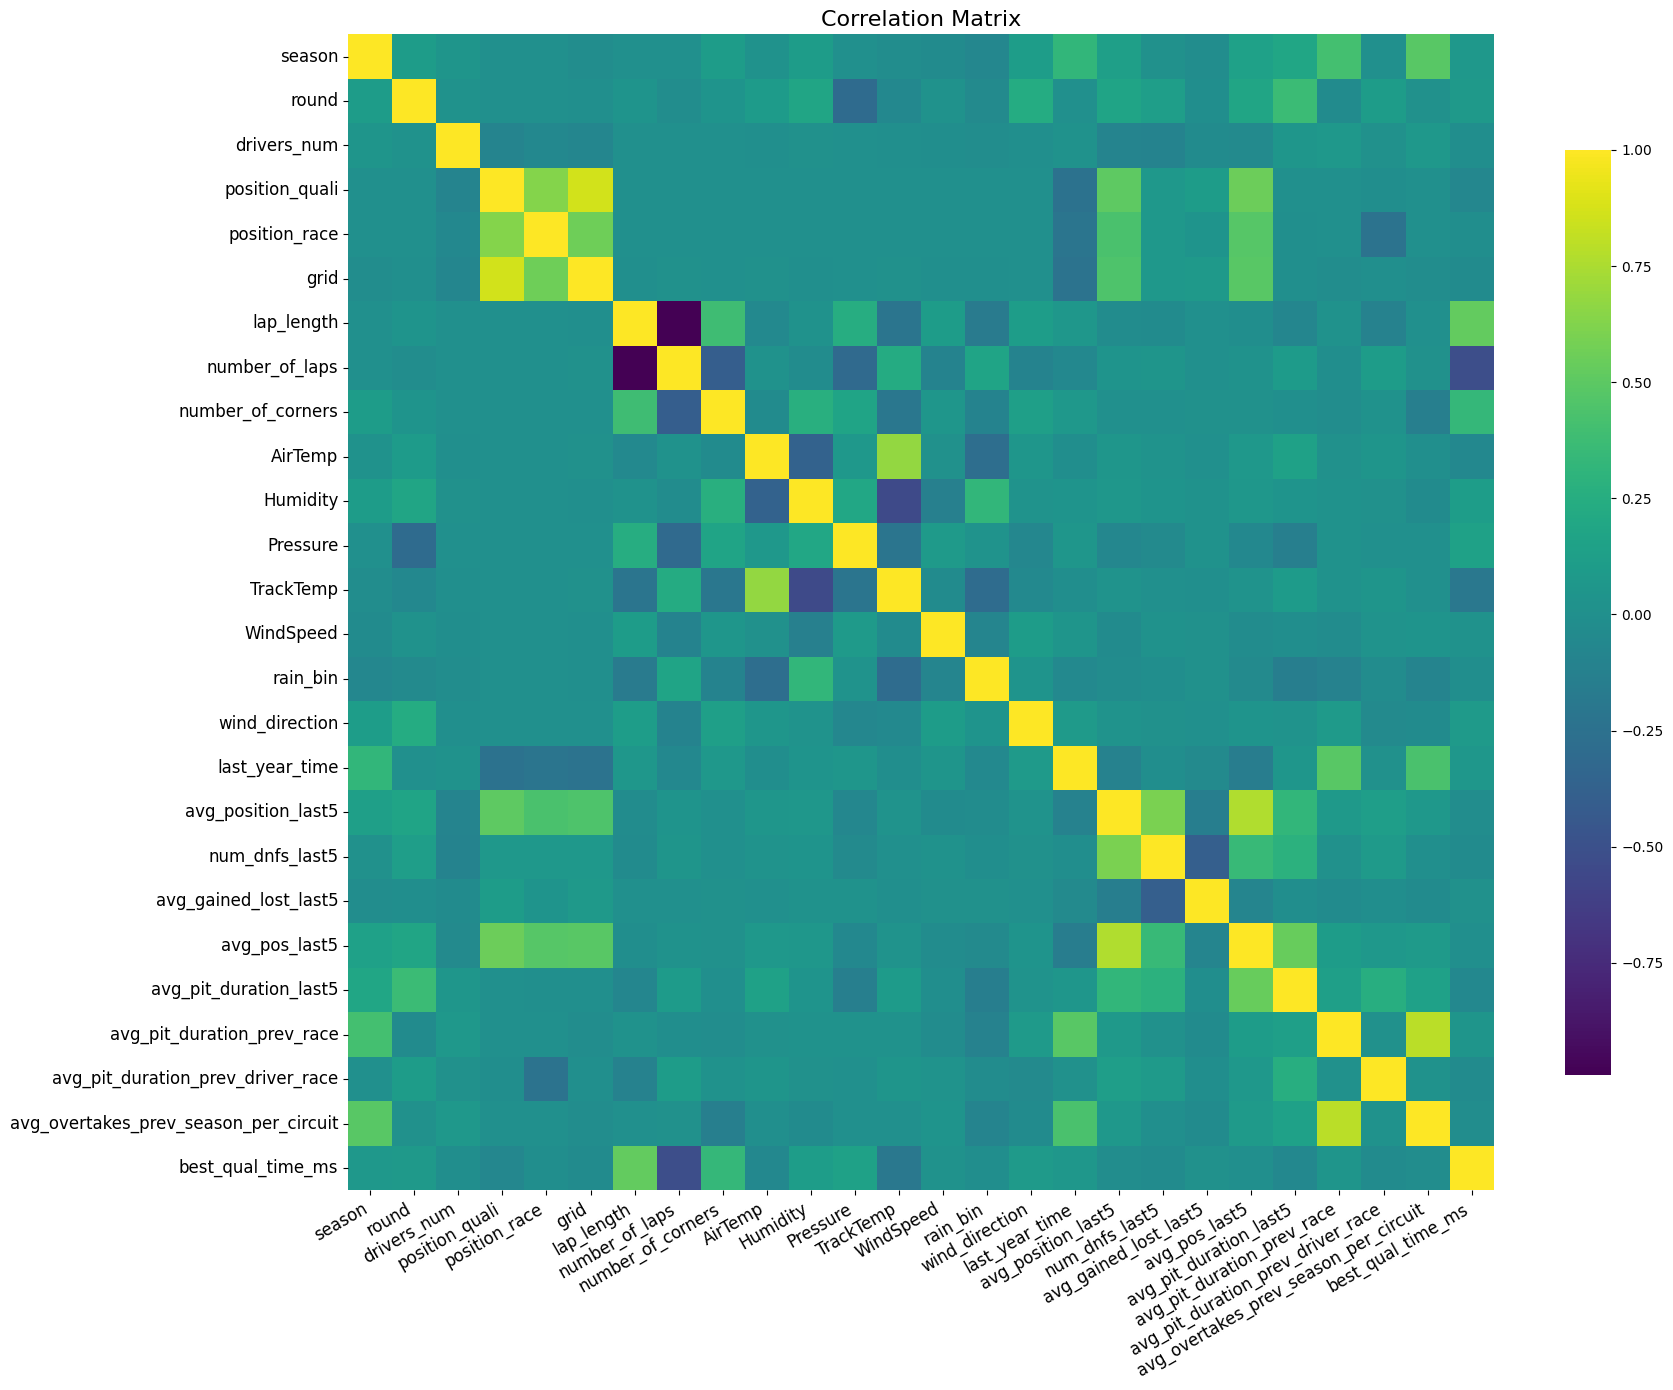

In [ ]:
# pravljenje matrice korelacije
plt.figure(figsize=(18, 14))
corr = df.select_dtypes(['number']).corr()

sns.heatmap(corr, annot=False, fmt=".2f", cmap='viridis',
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.8})

plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Feature Importances')

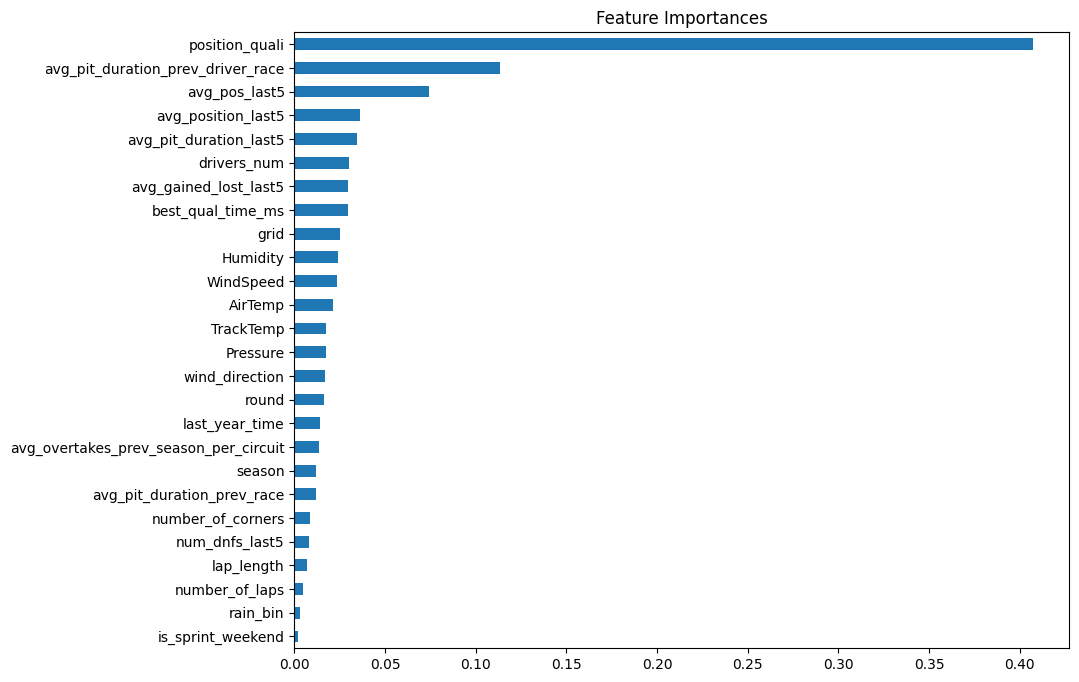

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['position_race']) 
y = df['position_race']

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("Feature Importances")


Text(0.5, 1.0, 'Mutual Information')

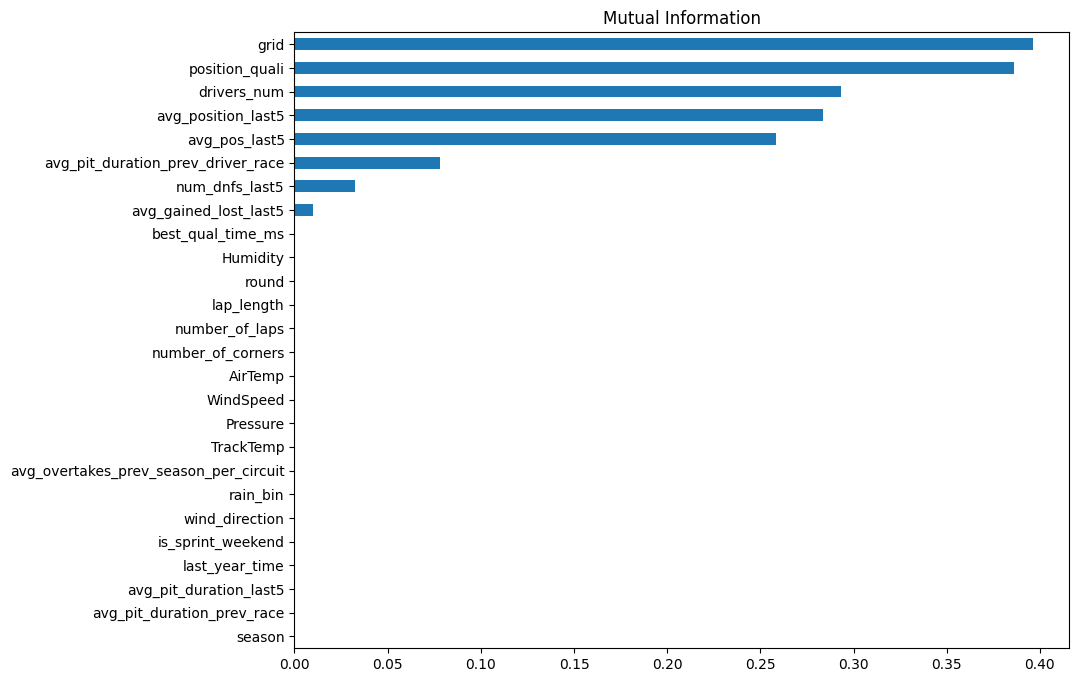

In [17]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns)
mi_series.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("Mutual Information")
